
# 03. Exploratory Data Analysis (EDA)




## 0. Load the data


In [61]:
import pandas as pd

customers = pd.read_csv('../data/cleaned/customers_features.csv')
offers = pd.read_csv('../data/cleaned/offers_clean.csv')
events = pd.read_csv('../data/cleaned/events_clean.csv')


## Part A: Customers table



### Q1. How many customers are in each age group?



In [62]:
customers["age_group"].value_counts().sort_index()

# 65+ is the largest group (4,266), 18-24 the smallest (876). Counts rise steadily with age.

age_group
18-24 Young Adults             876
25-34 Early Career            1380
35-44 Young Families          1869
45-54 Mature Professionals    3013
55-64 Pre-Retirement          3421
65+ Retirees                  4266
Name: count, dtype: int64


### Q2. How many customers are in each income group?



In [ ]:
customers["income_group"].value_counts().sort_index()

# 50-75k Middle is the largest group (6,436), 100-120k Affluent the smallest (1,006).
# most customers cluster in the two middle income bands (30-50k and 50-75k together are 10,470 of 14,825, about 71%)

income_group
100-120k Affluent       1006
30-50k Lower-Middle     4034
50-75k Middle           6436
75-100k Upper-Middle    3349
Name: count, dtype: int64


### Q3. How many customers are in each tenure group?



In [ ]:
customers["tenure_group"].value_counts().sort_values(ascending = False)

# New members are 51% of customers

tenure_group
New (<1yr)             7595
Established (1-3yr)    5905
Loyal (3-5yr)          1325
Name: count, dtype: int64


### Q4. What is the gender split?



In [68]:
customers["gender"].value_counts().sort_index()

# Male customers are more than a female custmers. so, the gender slit is not balanced.

gender
F    6129
M    8484
O     212
Name: count, dtype: int64


### Q5. Is age related to income?
A scatter plot or a group-by table (e.g. average income per age group). If age and income move together, an "older customers respond more" finding later could really be an income effect, or the reverse.


In [ ]:
customers.groupby("age_group", observed=True)["income"].mean().round(0)





age_group
18-24 Young Adults            50056.0
25-34 Early Career            51437.0
35-44 Young Families          58074.0
45-54 Mature Professionals    67425.0
55-64 Pre-Retirement          70604.0
65+ Retirees                  70691.0
Name: income, dtype: float64

In [ ]:
# a single number for the strength of the relationship (-1 to 1)
customers['age'].corr(customers['income'])

#  correlation between age and income is **0.307** — a real but weak-to-moderate positive relationship.
#  Average income rises steadily by age group, 
# from $50,056 (18-24) to $70,691 (65+), with the biggest jump between 25-34 ($51,437) and 35-44 ($58,074).


### Q6. When did most customers join?



In [ ]:
customers["became_member_on"] = pd.to_datetime(customers["became_member_on"])

customers["became_member_on"].dt.to_period("Y").value_counts().sort_index()

 # membership grew every year through 2017. 2018 looks like a drop, but the data only runs to July 2018 (about 7 months),
 #  while every other year has a full 12 months — so 2018 is on pace to be the biggest year yet, not a decline. 



## Part B: Offers table



### Q7. How many offers are there of each type (bogo, discount, informational)?



In [71]:
offers["offer_type"].value_counts()

offer_type
bogo             4
discount         4
informational    2
Name: count, dtype: int64


### Q8. What are the difficulty and reward values across the 10 offers?
A simple table, sorted by type then difficulty. This is the first look at the offer structure that later becomes the `offer_label` (e.g. `discount-7-3-7`).


In [ ]:

offers.sort_values(['offer_type', 'difficulty'])[['offer_id', 'offer_type', 'difficulty', 'reward', 'duration']]

# in every BOGO offer, `reward` equals `difficulty` (spend $5 get $5, spend $10 get $10). 
# In every discount offer, `reward` is well below `difficulty` (spend $7 get $3, spend $20 get $5).
#  Informational offers have `difficulty = reward = 0`.

,offer_id,offer_type,difficulty,reward,duration
3,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7
8,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5
0,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7
1,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5
5,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,7,3,7
6,fafdcd668e3743c1bb461111dcafc2a4,discount,10,2,10
9,2906b810c7d4411798c6938adc9daaa5,discount,10,2,7
4,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20,5,10
2,3f207df678b143eea3cee63160fa8bed,informational,0,0,4
7,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,3



### Q9. Which offers use which channels, and how many use social?
`channels` is stored as text that looks like a list (e.g. `"['email', 'mobile']"`), so convert it with `ast.literal_eval` before checking membership. 

In [ ]:

import ast
offers['channels_list'] = offers['channels'].apply(ast.literal_eval)
offers['has_social'] = offers['channels_list'].apply(lambda ch: 'social' in ch)

offers[['offer_type', 'difficulty', 'reward', 'duration', 'channels_list', 'has_social']]

# 6 of 10 offers use social. By type: 3 of 4 bogo, 2 of 4 discount, 1 of 2 informational use social.


,offer_type,difficulty,reward,duration,channels_list,has_social
0,bogo,10,10,7,"[email, mobile, social]",True
1,bogo,10,10,5,"[web, email, mobile, social]",True
2,informational,0,0,4,"[web, email, mobile]",False
3,bogo,5,5,7,"[web, email, mobile]",False
4,discount,20,5,10,"[web, email]",False
5,discount,7,3,7,"[web, email, mobile, social]",True
6,discount,10,2,10,"[web, email, mobile, social]",True
7,informational,0,0,3,"[email, mobile, social]",True
8,bogo,5,5,5,"[web, email, mobile, social]",True
9,discount,10,2,7,"[web, email, mobile]",False


In [ ]:

print("offers using social:", offers['has_social'].sum(), "of", len(offers))

# social is not evenly spread across offer types — discount offers are the *least* likely to use it (only 2 of 4). 
# This is worth remembering before concluding "discount offers perform worse on visibility". 
# it could be a channel effect (fewer discount offers use social) rather than something about discounts themselves.

offers using social: 6 of 10



### Q10. How long does each offer last?


In [75]:

offers['duration'].describe()


count    10.000000
mean      6.500000
std       2.321398
min       3.000000
25%       5.000000
50%       7.000000
75%       7.000000
max      10.000000
Name: duration, dtype: float64

In [ ]:
offers.groupby('offer_type')['duration'].agg(['min', 'max'])

# discount offers get the longest windows to respond, informational the shortest.
# Combined with the reward table above, discount offers ask for more effort per dollar of reward 
# but also give more time — those two design choices may offset each other.

,min,max
offer_type,,
bogo,5,7
discount,7,10
informational,3,4



## Part C: Events table



### Q11. How many events are there of each type (received, viewed, completed, transaction)?


In [77]:
events["event"].value_counts()


# transactions are more compared to offer receives. 
# so, it means that one customer has done the multiple transactions within the one month period.
# not every transaction is necessarily tied to an offer. Many of these purchases likely happen with no active offer at all 

event
transaction        123957
offer received      66501
offer viewed        49860
offer completed     32070
Name: count, dtype: int64


### Q12. How many events does a typical customer have?
The distribution of event count per `customer_id` (e.g. with `.value_counts()` or `.describe()`). Shows whether most customers are lightly or heavily engaged, and whether a few customers dominate the event log.


In [ ]:
events_per_customer = events.groupby("customer_id").size()

events_per_customer.describe()

# per  customer has done the transaction minumum 2 and maximum 51. 
# But we donot know wheather they have completed the transations after viewing the offer or just purchase randomly.


count    14825.000000
mean        18.373558
std          6.919675
min          2.000000
25%         13.000000
50%         18.000000
75%         23.000000
max         51.000000
dtype: float64

### Q13. How is `time` distributed across the 30 days?


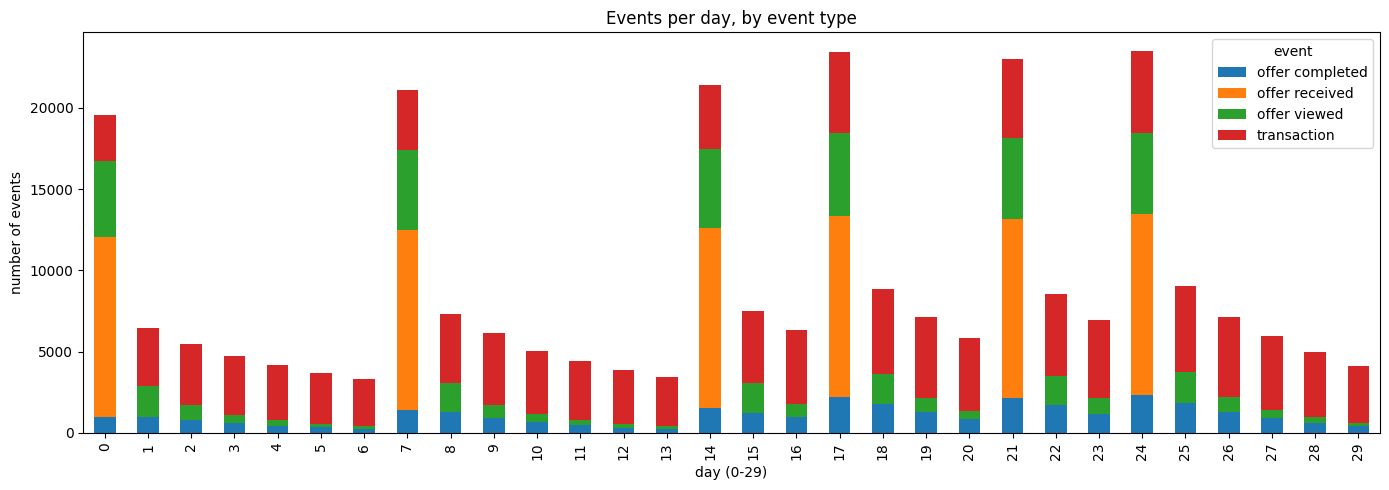

Days with any 'offer received' event: [np.int64(0), np.int64(7), np.int64(14), np.int64(17), np.int64(21), np.int64(24)]


In [ ]:
# day 0-29 (24-hour buckets from the start of the 30-day period)
events['day'] = events['time'] // 24


# ---- by day, split by event type ----
by_day_type = events.groupby(['day', 'event']).size().unstack(fill_value=0)

by_day_type.plot(kind='bar', stacked=True, figsize=(14, 5))
plt.xlabel('day (0-29)')
plt.ylabel('number of events')
plt.title('Events per day, by event type')
plt.legend(title='event')
plt.tight_layout()
plt.show()



# ---- which exact days do offers go out? ----
receive_days = sorted(events.loc[events['event'].eq('offer received'), 'day'].unique())
print("Days with any 'offer received' event:", receive_days)



- 'offer received` (orange) appears on only 6 of 30 days — 0, 7, 14, 17, 21, 24. Sends are weekly for the first two (0, 7), then every 3-4 days after that, so days 14-27 look busier even though each send is roughly the same size (~11,000-11,100 offers).

- 'offer completed` (blue) grows across the chart even though every send is the same size — roughly doubling from day 0 to day 24. 
- `transaction` (red) never disappears, even on the quietest days (5, 6, 12, 13), showing most purchases happen independently of offer activity.

Note:  the rising completion trend could mean customers are responding better over time, or that later offers are just easier to complete — this chart alone can't tell the two apart.


### Q14. What is the distribution of transaction amounts?


In [ ]:
tx = events.loc[events["event"].eq("transaction"), "amount"]
tx.describe()

# mean $13.996, median $10.80, skew ≈ 18.5 — strongly right-skewed, 
# as expected: most purchases are small, a few are very large (max $1,062.28).

count    123957.000000
mean         13.996325
std          31.749420
min           0.050000
25%           3.660000
50%          10.800000
75%          19.130000
max        1062.280000
Name: amount, dtype: float64

skew: 18.53


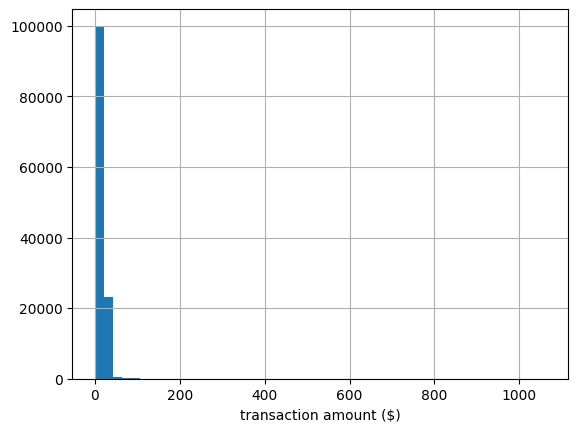

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("skew:", tx.skew().round(2))    # positive = a long tail of large purchases

tx.hist(bins=50)
plt.xlabel('transaction amount ($)')
plt.show()

#  skew this high means the mean is a misleading "typical" value — 
# the median ($10.80) represents a normal purchase far better than the mean ($14.00). 




### Q14. Are transactions above $20 valid or possible outliers?
We will answer three smaller questions:
1. Which transactions are above $20?
2. Are they concentrated among only a few customers?
3. Do the cleaned amounts match the original raw data?


In [ ]:
transactions = events.loc[
    events["event"].eq("transaction"),
    ["customer_id", "time", "amount"]
].copy()

high_value = transactions.loc[transactions["amount"] > 20].sort_values(
    "amount", ascending=False
)

print("Transactions greater than $20:", len(high_value))
display(high_value)



Transactions greater than $20: 28154


,customer_id,time,amount
252449,6cf884a6c5ae4b2daccb6d3108028fef,630,1062.28
268139,454b00bdd77c4f588eb9f6cafd81dc5d,690,1015.73
37544,5ecaea5c8bf44ae4a65838d9d066c909,102,1001.85
124684,dce784e26f294101999d000fad9089bb,372,989.34
269193,52959f19113e4241a8cb3bef486c6412,696,977.78
...,...,...,...
171321,6f342b3100534c42bd8cd4763b368abe,468,20.01
40216,cee3677420e24b288b39394ecddf9825,114,20.01
260121,0578d2389a8f4e4a81f4d2648b85293e,654,20.01
175320,8140d90b53c54b0687ddd58ee64bd9d6,486,20.01



### Q14a. Are the high-value transactions concentrated among a few customers?
Count distinct customers and summarize each customer's high-value transactions.


In [ ]:
print("Customers making transactions above $20:", high_value["customer_id"].nunique())
print(
    "Share of all transaction rows:",
    round(len(high_value) / len(transactions) * 100, 2),
    "%"
)

display(
    high_value.groupby("customer_id")["amount"].agg(
        transaction_count="count",
        total_amount="sum",
        average_amount="mean",
        largest_amount="max"
    ).sort_values("transaction_count", ascending=False)
)

# 28,154 of 123,957 transactions (22.71%) are above $20, spread across 7,938 of 14,825 customers (53.6% of all customers).
# The heaviest customer has 16 such transactions.
# so, trabsactions above 20 are notoutliers. This is just the right-hand side 
# of a right-skewed distribution (consistent with the skew ≈ 18.5 found above), not a data-quality problem.

 Q15. How many offers does a typical customer receive, and does that vary by customer?

In [ ]:

offers_received_per_customer = events[events['event'].eq('offer received')].groupby('customer_id').size()
offers_received_per_customer.describe()



count    14820.000000
mean         4.487247
std          1.071711
min          1.000000
25%          4.000000
50%          5.000000
75%          5.000000
max          6.000000
dtype: float64

In [ ]:
# how many "offer received" events are a repeat of the same customer + same offer
dup_receipts = events[events['event'].eq('offer received')].duplicated(['customer_id', 'offer_id'], keep=False).sum()
print("received events that repeat a customer+offer pair:", dup_receipts)

# customers receive 1 to 6 offers each (mean 4.49). 
# 21,451 "offer received" events are a repeat of the same customer and the same offer.

received events that repeat a customer+offer pair: 21451



## Summary

**Customers:** skews older (65+ is the biggest age group, 18-24 the smallest) and mid-income (50-75k is the biggest income group, 100-120k the smallest. Men outnumber women 57% to 41%. Age and income move together only weakly (correlation 0.31). Membership grew every year through 2017; 2018 only looks lower because the data cuts off mid-year. About half of customers are "New" (<1yr) by tenure.

**Offers:** 10 offers total — 4 bogo, 4 discount, 2 informational. BOGO always refunds the full spend (reward = difficulty); discount never does. 6 of 10 offers use social media, but unevenly (3/4 bogo, 2/4 discount, 1/2 informational). so, there is channel imbalance to send an offer. Discount offers get the longest windows (7-10 days), informational the shortest (3-4 days).

**Events:** 272,388 events — mostly transactions (124k), then received (66.5k), viewed (50k), completed (32k). A typical customer has 18 events, but this ranges from 2 to 51. Offers are sent in exactly 6 scheduled batches (days 0, 7, 14, 17, 21, 24), each about the same size (~11,000 receipts) — not a continuous rollout. Completions per batch roughly double from the first send to the last, while transactions never drop to zero even on days with no offer activity at all.

**Transaction amounts** are strongly right-skewed (skew ≈ 18.5; mean $14.00 vs median $10.80). Values above $20 are common (23% of transactions, 54% of customers), so they are not considered as outliers.

